* Name: Nicholas Ian Stephen
* Username: nicholas
* Student s-number: s6089003
* Group (AS1, etc.): AS5

In [39]:
#SQ 5.2
import numpy as np
if str(input()) == "numbers.txt": #If the user input is the correct file
    text = np.loadtxt("numbers.txt") #Load the text from the file 
    print(text)
    x = text[:,0]
    y = text[:,1] #Separate the columns
    print(f"x:{x}, mean {np.mean(x)}, min {np.min(x)}, max {np.max(np.max(x))}")
    print(f"y:{y}, mean {np.mean(y)}, min {np.min(y)}, max {np.max(np.max(y))}") #Print the requred data
    y_med = np.median(y)
    print(F"y_med: {y_med}")
    y2 = (y - y_med)**2 #Calculating the new array 
    y21 = np.array(y2)
    print(y2)    
else:
    print("not correct file!!")

 numbers.txt


[[12. 14.]
 [67. 69.]
 [57. 25.]
 [20. 11.]
 [20. 25.]
 [58. 41.]
 [18. 19.]
 [68. 67.]
 [ 6.  5.]
 [70. 15.]]
x:[12. 67. 57. 20. 20. 58. 18. 68.  6. 70.], mean 39.6, min 6.0, max 70.0
y:[14. 69. 25. 11. 25. 41. 19. 67.  5. 15.], mean 29.1, min 5.0, max 69.0
y_med: 22.0
[  64. 2209.    9.  121.    9.  361.    9. 2025.  289.   49.]


In [42]:
#SQ 5.6
import numpy as np

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

#Concatenate
c = np.concatenate((a, b))

print(f"The shape is {c.shape}") #Print the shape
np.concatenate((a, b)) #Not printing for some reason

print(np.concatenate((a, b), axis=0))#No noticable change
print(f"Axis 1 gives error: axis 1 is out of bounds for array of dimension 1")

The shape is (6,)
[1 2 3 4 5 6]
Axis 1 gives error: axis 1 is out of bounds for array of dimension 1


In [3]:
import numpy as np

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

np.concatenate((a, b))

array([1, 2, 3, 4, 5, 6])

In [38]:
import numpy as np

a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])

np.concatenate((a, b), axis=1)
#Difference in how its arranged

array([[1, 2, 5, 6],
       [3, 4, 7, 8]])

In [28]:
c = np.array([[1, 2], [3, 4]])
d = np.array([[5, 6], [7, 8]])

np.concatenate((c, d))

array([[1, 2],
       [3, 4],
       [5, 6],
       [7, 8]])

C:\Users\myste\AppData\Local\Temp\ipykernel_16192\1776583137.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  arr = imageio.imread('m101BW.jpg')


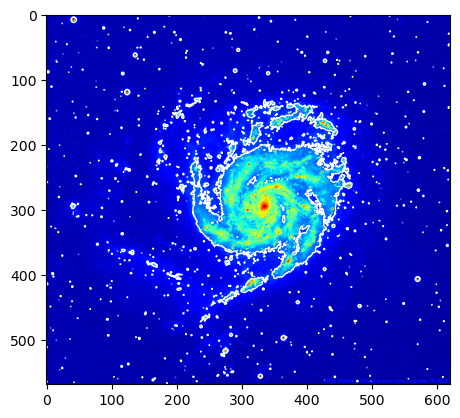

In [56]:
#SQ 5.9
import imageio 
import matplotlib.pyplot as plt
arr = imageio.imread('m101BW.jpg') #Reads the filename 
fig, ax = plt.subplots() #Create figure and plot axes
ax.imshow(arr,cmap="jet") #Show with jet colour map
# Make a contour plot on top of the image with levels to avoid noisy areas

#Set the contour settings
vmin, vmax = np.percentile(arr, [90,100]) #Top 10 percentile
nlevels = 1 #1 contour
levels = np.linspace(vmin, vmax, nlevels)

#Overlay the contour
contours = ax.contour(arr, levels=levels, colors='white', linewidths=1)


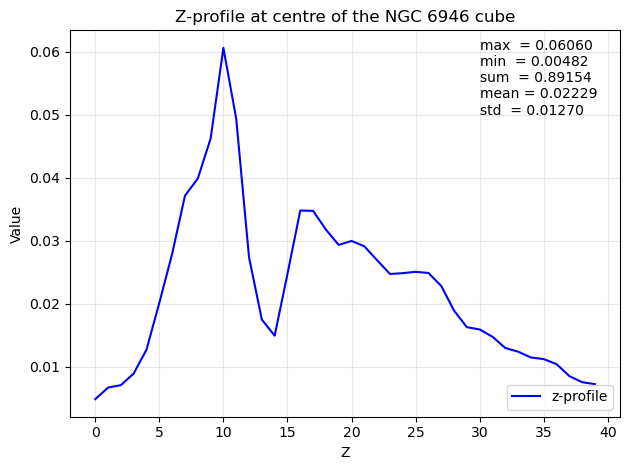

In [12]:
#SQ 5.10
import numpy as np
import matplotlib.pyplot as plt

#Get the data file
file = "ngc6946.txt"

#Load data and reshape to cube with 40 planes, 50 rows, 70 columns
data = np.loadtxt(file)
cube = data.reshape(40, 50, 70)

#Z profile at the centre of the x, y plane (tot/2 for rows and columns)
xc, yc = 35, 25
z = cube[:, yc, xc]

#Elementary statistics
p_max = np.max(z)
p_min = np.min(z)
p_sum = np.sum(z)
p_mean = np.mean(z)
p_std = np.std(z)

#Plot
fig, ax = plt.subplots()
z_axis = np.arange(40)
ax.plot(z_axis, z, "b-", linewidth=1.5, label="z-profile")
plt.text( 30, 0.05, #Show the data on the graph
    f"max  = {p_max:.5f}\n"
    f"min  = {p_min:.5f}\n"
    f"sum  = {p_sum:.5f}\n"
    f"mean = {p_mean:.5f}\n"
    f"std  = {p_std:.5f}" 
)

ax.set_xlabel("Z")
ax.set_ylabel("Value")
ax.set_title("Z-profile at centre of the NGC 6946 cube")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

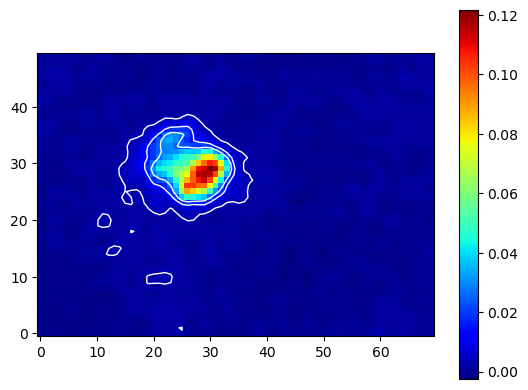

In [36]:
#SQ 5.11
import numpy as np
import matplotlib.pyplot as plt

#Get the data file
file = "ngc6946.txt"

#Load data and reshape 
data = np.loadtxt(file)
cube = data.reshape(40, 50, 70)

#Extract the first plane
cube1 = cube[0]

fig, ax = plt.subplots()

#Calculate necessary
mean = np.mean(cube1)
std = np.std(cube1)
mstd = mean + std
m2std = mean + 2*std

#Set contour levels
L1 = mean 
L2 = mstd
L3 = m2std

#Overlay the contours
img = ax.imshow(cube1, origin='lower', cmap='jet')
contour1 = ax.contour(cube1, levels=[L1, L2, L3], colors='white', linewidths=1)
fig.colorbar(img, ax=ax)

In [37]:
#SQ 5.12
from scipy.constants import c

class Galaxy:    
    """Class for redshift calculation of galaxies"""  
        
    caH_0 = 3968.5      # Calcium H line in rest frame
    c = c                # speed of light in m/s from scipy.constants

    def __init__(self, name, calciumHline=caH_0):
        self.name = name
        self.caH = calciumHline

    def redshift(self):        
        z = (self.caH - self.caH_0) / self.caH
        return z

    def velocity(self): #Gives velocity based on v = z * c, converted to km/s
        z = self.redshift()
        v_ms = z * self.c
        v_kms = v_ms / 1000
        return v_kms

# Example:
g = Galaxy(name="Galaxy 1", calciumHline=4150)  
print("Velocity of", g.name, ":", g.velocity(), "km/s")

Velocity of Galaxy 1 : 13111.405090843375 km/s


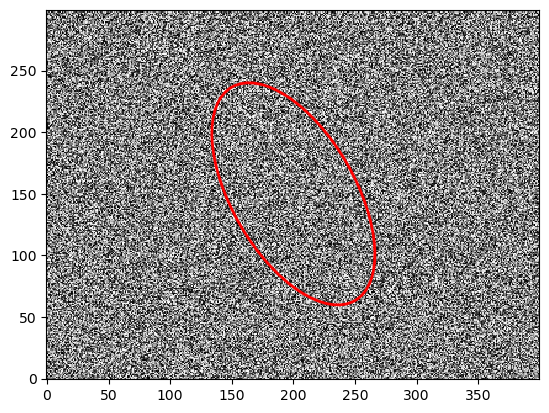

In [54]:
#SQ 5.13
import numpy as np
from matplotlib.pyplot import figure, show, subplots
import matplotlib.pyplot as plt
Nx = 400
Ny = 300
data = np.random.random((Ny,Nx))

#Show the image
fig, ax = plt.subplots()
ax.imshow(data, interpolation='none', origin="lower", cmap='gray')

from matplotlib.patches import Ellipse

class AstroEllipse(Ellipse):
   def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
      # We use the (sort of) astronomical angle where 'angle' defines)
      # the position angle of the major axis of a ring projected onto the sky
      # (i.e. an ellipse). This is an angle taken in anti-clockwise direction between
      # the north direction on the sky and the major axis of the receding half of the
      # galaxy (Rots 1975, astron, astrophys 45, 43).
      # Here we assume (!) north is in the positive Y direction.
      # If not, you need to correct the angle for the rotation of the image.
      # Parameter 'position_angle' enters in degrees
      assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
      XY = (xc, yc)                  # MPL requires center as a tuple
      angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
      height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
      width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
      super().__init__(XY, width, height, angle=angle_mpl, **args)

#Plot ellipse in center of image
xc = Nx // 2
yc = Ny // 2
semi_major = 100
semi_minor = 50
position_angle = 30.0

#Add the ellipse to the image with centring 
ellipse = AstroEllipse(xc, yc, semi_major, semi_minor, position_angle, edgecolor='red', facecolor='none', linewidth=2)
ax.add_patch(ellipse)

#Show
show()